# Análise Exploratória de Dados - FIFA World Cup 2026
Este notebook apresenta a etapa de EDA do dataset `data/train.csv` para entender como as características se relacionam com a variável alvo `winner`.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from eda import ExploradorDados

sns.set_theme(style="whitegrid")
explorador = ExploradorDados("data/train.csv")

## 1. Carregamento e visão geral dos dados
A primeira etapa consiste em carregar o dataset e verificar o número de linhas, colunas, tipos de dados e valores ausentes.

In [11]:
relatorio = explorador.relatorio_geral()
print("---")
print("Shape:", relatorio["shape"])
print("---")
print("Tipos das colunas:")
print(pd.Series(relatorio["dtypes"]))


=== Visão Geral do Dataset ===
Linhas: 1000
Colunas: 26

Tipos de cada coluna:
team_name                       str
country_code                    str
confederation                   str
fifa_rank                     int64
fifa_points                 float64
wins_last_10_matches          int64
losses_last_10_matches        int64
draws_last_10_matches         int64
win_rate_last_year          float64
goals_scored_avg            float64
goals_conceded_avg          float64
clean_sheets_last_10          int64
shots_per_game              float64
shots_on_target_ratio       float64
avg_player_rating           float64
star_players_count            int64
market_value_million_eur    float64
experience_avg_caps           int64
coach_experience_years        int64
recent_form_score           float64
possession_avg              float64
passing_accuracy            float64
host_advantage                int64
travel_distance_avg         float64
climate_similarity_score    float64
winner              

## 2. Separação de variáveis categóricas e numéricas
Aqui identificamos as colunas categóricas e numéricas automaticamente para orientar a análise.

In [12]:
colunas_categoricas, colunas_numericas = explorador.separar_variaveis()
print("---")
print("Colunas categóricas:", colunas_categoricas)
print("Colunas numéricas:", colunas_numericas)


=== Separação de Variáveis ===
Colunas categóricas (3): ['team_name', 'country_code', 'confederation']
Colunas numéricas (23): ['fifa_rank', 'fifa_points', 'wins_last_10_matches', 'losses_last_10_matches', 'draws_last_10_matches', 'win_rate_last_year', 'goals_scored_avg', 'goals_conceded_avg', 'clean_sheets_last_10', 'shots_per_game', 'shots_on_target_ratio', 'avg_player_rating', 'star_players_count', 'market_value_million_eur', 'experience_avg_caps', 'coach_experience_years', 'recent_form_score', 'possession_avg', 'passing_accuracy', 'host_advantage', 'travel_distance_avg', 'climate_similarity_score', 'winner']
---
Colunas categóricas: ['team_name', 'country_code', 'confederation']
Colunas numéricas: ['fifa_rank', 'fifa_points', 'wins_last_10_matches', 'losses_last_10_matches', 'draws_last_10_matches', 'win_rate_last_year', 'goals_scored_avg', 'goals_conceded_avg', 'clean_sheets_last_10', 'shots_per_game', 'shots_on_target_ratio', 'avg_player_rating', 'star_players_count', 'market_va

## 3. Agrupamentos com a variável alvo `winner`
Fazemos três agrupamentos inteligentes que relacionam `winner` com `confederation`, `fifa_rank` e `market_value_million_eur`.

In [13]:
agrupamentos = explorador.criar_agrupamentos()
print("---\nResumo por confederação:")
print(agrupamentos["confederation"])


=== Agrupamento por Confederação ===
  confederation  total_times  taxa_vitoria
0      CONMEBOL          180      0.550000
1          UEFA          444      0.538288
2      CONCACAF          109      0.431193
3           AFC          107      0.355140
4           CAF          143      0.328671
5           OFC           17      0.176471

=== Agrupamento por Faixa de Ranking FIFA ===
        fifa_rank  total_times  taxa_vitoria
0  (-0.001, 10.0]          275      0.716364
1    (10.0, 20.0]          217      0.516129
2    (20.0, 50.0]          508      0.322835

=== Agrupamento por Quartil de Valor de Mercado ===
  market_value_million_eur  total_times  taxa_vitoria  valor_medio
0         (199.999, 308.0]          251      0.270916     0.270916
1           (308.0, 436.0]          249      0.385542     0.385542
2          (436.0, 706.25]          250      0.520000     0.520000
3         (706.25, 1198.0]          250      0.716000     0.716000
---
Resumo por confederação:
  confederation  

In [14]:
print("---\nResumo por faixa de ranking FIFA:")
print(agrupamentos["fifa_rank_bins"])

---
Resumo por faixa de ranking FIFA:
        fifa_rank  total_times  taxa_vitoria
0  (-0.001, 10.0]          275      0.716364
1    (10.0, 20.0]          217      0.516129
2    (20.0, 50.0]          508      0.322835


In [15]:
print("---\nResumo por quartil de valor de mercado:")
print(agrupamentos["market_value_quartiles"])

---
Resumo por quartil de valor de mercado:
  market_value_million_eur  total_times  taxa_vitoria  valor_medio
0         (199.999, 308.0]          251      0.270916     0.270916
1           (308.0, 436.0]          249      0.385542     0.385542
2          (436.0, 706.25]          250      0.520000     0.520000
3         (706.25, 1198.0]          250      0.716000     0.716000


## 4. Gráfico de barras da variável alvo
Visualizamos a distribuição de `winner` para entender o balanceamento entre vencedores e não vencedores.

c:\Users\leone\Documents\GitHub\OATs\Dende-ROMA-Modelo-Preditivo-Dados-OAT4\eda.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=self.coluna_alvo, data=df, palette="pastel")


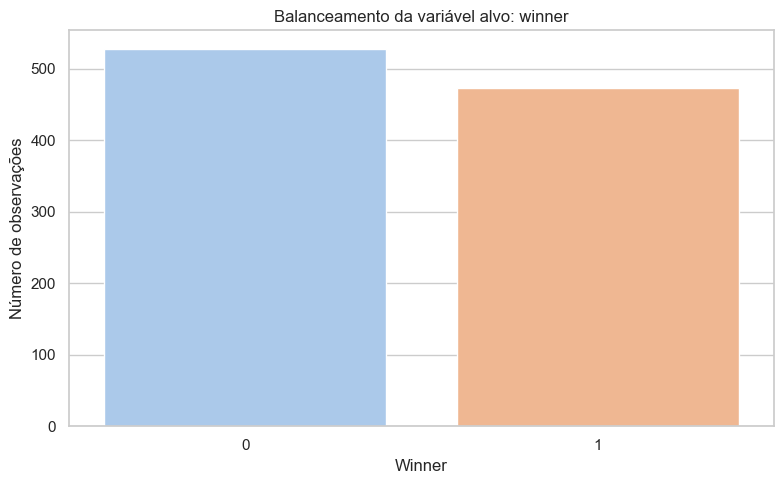

In [16]:
explorador.plotar_balanceamento_alvo()

## 5. Boxplot de valor de mercado por resultado
O boxplot mostra como o valor de mercado médio difere entre times vencedores e não vencedores.

c:\Users\leone\Documents\GitHub\OATs\Dende-ROMA-Modelo-Preditivo-Dados-OAT4\eda.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=self.coluna_alvo, y="market_value_million_eur", data=df, palette="muted")


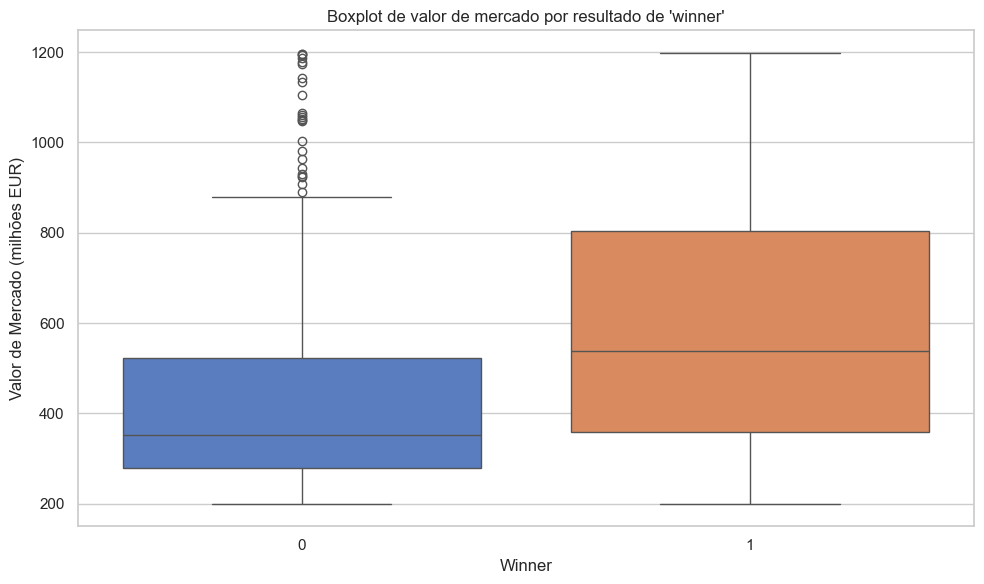

In [17]:
explorador.plotar_boxplot_valor_mercado()

## 6. Heatmap de correlação das variáveis mais impactantes
Selecionamos as 10 variáveis numéricas mais correlacionadas com `winner` e mostramos a matriz de correlação.

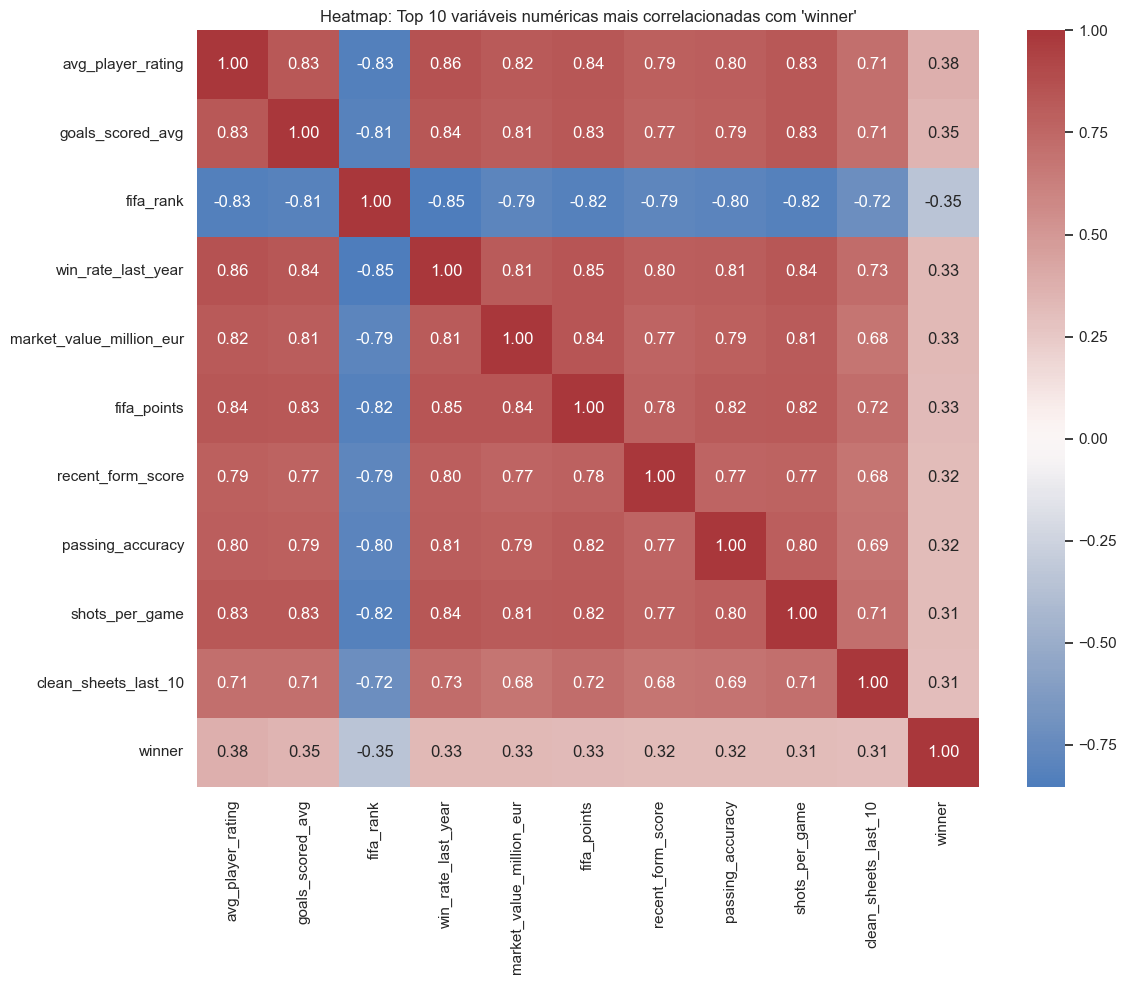

In [18]:
explorador.plotar_heatmap_correlacao()